### **De Bag-of-Words a MLP: Clasificación de texto con PyTorch**

Este cuaderno reorganiza el material y trata los siguientes temas:

- Perceptrón como baseline lineal
- MLP básico en PyTorch
- Función de pérdida y retropropagación
- Aplicación a una **tarea elemental de texto**
- Visualización de **pérdida** y **exactitud**
- Análisis inicial de errores

La idea pedagógica es simple: primero representamos cada texto como un vector **bag-of-words**, luego entrenamos un perceptrón y finalmente un **MLP** con una capa oculta.


#### **1. Importaciones y configuración**

In [1]:
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

torch.set_num_threads(1)

def set_seed(seed=7):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(7)
print("PyTorch:", torch.__version__)


PyTorch: 2.4.1+cpu


#### **2. Idea del experimento**

En esta práctica cada texto se convierte en un vector de conteos.

Si el vocabulario tiene tamaño $V$, entonces cada ejemplo entra a la red como un vector de dimensión $V$.

Trabajaremos con dos modelos:

1. **Perceptrón/clasificador lineal**: `Linear(V, 2)`
2. **MLP**: `Linear(V, h) -> ReLU -> Linear(h, 2)`

Usaremos `CrossEntropyLoss`, que es la pérdida estándar para clasificación multiclase con logits.


#### **3. Utilidades de preprocesamiento y entrenamiento**

In [2]:
LABELS = {0: "negativo", 1: "positivo"}

def tokenize(text):
    return re.findall(r"[a-záéíóúñü]+", text.lower())

def build_vocab(texts, min_freq=1):
    freq = {}
    for text in texts:
        for token in tokenize(text):
            freq[token] = freq.get(token, 0) + 1
    vocab = {
        token: idx
        for idx, (token, count) in enumerate(sorted(freq.items()))
        if count >= min_freq
    }
    return vocab, freq

def vectorize_bow(texts, vocab):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float32)
    for i, text in enumerate(texts):
        for token in tokenize(text):
            j = vocab.get(token)
            if j is not None:
                X[i, j] += 1.0
    return X

def accuracy_score_np(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float((y_true == y_pred).mean())

def f1_binary_np(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

def evaluate_model(model, X, y, loss_func):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        loss = float(loss_func(logits, y))
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
    y_true = y.cpu().numpy()
    y_pred = preds.cpu().numpy()
    return {
        "loss": loss,
        "acc": accuracy_score_np(y_true, y_pred),
        "f1": f1_binary_np(y_true, y_pred),
        "probs": probs.cpu().numpy(),
        "preds": y_pred,
    }

def train_model(model, X_train, y_train, X_val, y_val, epochs=20, lr=0.03, batch_size=8):
    loss_func = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    n = len(X_train)

    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(n)
        train_losses = []
        train_true = []
        train_pred = []

        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb = X_train[idx]
            yb = y_train[idx]

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_func(logits, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(float(loss.detach()))
            train_true.extend(yb.cpu().numpy().tolist())
            train_pred.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())

        val_metrics = evaluate_model(model, X_val, y_val, loss_func)
        history.append(
            {
                "epoch": epoch,
                "train_loss": float(np.mean(train_losses)),
                "train_acc": accuracy_score_np(train_true, train_pred),
                "train_f1": f1_binary_np(train_true, train_pred),
                "val_loss": val_metrics["loss"],
                "val_acc": val_metrics["acc"],
                "val_f1": val_metrics["f1"],
            }
        )

    return pd.DataFrame(history)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"], label="train")
    axes[0].plot(history["epoch"], history["val_loss"], label="validación")
    axes[0].set_title(f"{title} - pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_acc"], label="train")
    axes[1].plot(history["epoch"], history["val_acc"], label="validación")
    axes[1].set_title(f"{title} - exactitud")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def summarize_split(name, texts, labels):
    labels = np.asarray(labels)
    print(f"{name}: {len(texts)} ejemplos")
    print("  positivos:", int((labels == 1).sum()))
    print("  negativos:", int((labels == 0).sum()))


#### **4. Corpus pequeño de sentimiento en español**

In [3]:
train_positive = [
    "el producto es bueno y util",
    "la pelicula es buena y entretenida",
    "el servicio fue bueno y rapido",
    "la clase fue clara y buena",
    "la app funciona bien y es estable",
    "el libro es bueno y facil",
    "la comida estuvo buena y fresca",
    "la presentacion fue clara y util",
    "el audio suena bien y limpio",
    "la interfaz se ve bien y moderna",
    "el laboratorio fue bueno y dinamico",
    "la explicacion fue clara y precisa",
    "el resultado fue bueno y estable",
    "el tutorial fue util y claro",
    "la experiencia fue buena y agradable",
    "la bateria dura bien y carga rapido",
    "el codigo esta bien organizado",
    "la solucion fue simple y efectiva",
    "el soporte fue rapido y amable",
    "la practica fue buena y formativa",
]

train_negative = [
    "el producto es malo y poco util",
    "la pelicula es mala y aburrida",
    "el servicio fue malo y lento",
    "la clase fue confusa y mala",
    "la app funciona mal y falla",
    "el libro es malo y dificil",
    "la comida estuvo mala y fria",
    "la presentacion fue confusa y larga",
    "el audio suena mal y saturado",
    "la interfaz se ve mal y anticuada",
    "el laboratorio fue malo y aburrido",
    "la explicacion fue confusa e imprecisa",
    "el resultado fue malo e inestable",
    "el tutorial fue inutil y confuso",
    "la experiencia fue mala y desagradable",
    "la bateria dura poco y carga lento",
    "el codigo esta mal organizado",
    "la solucion fue torpe e inefectiva",
    "el soporte fue lento y descortes",
    "la practica fue mala y frustrante",
]

val_positive = [
    "la documentacion es buena",
    "la solucion fue correcta",
    "el sistema fue estable",
    "la practica fue util",
]

val_negative = [
    "la documentacion es mala",
    "la solucion fue incorrecta",
    "el sistema fue inestable",
    "la practica fue frustrante",
]

# Este conjunto de prueba incluye ejemplos mas faciles y algunos casos dificiles
# con negacion o mezcla de pistas positivas y negativas.
test_texts = [
    "el producto es bueno",
    "la pelicula fue mala",
    "la clase fue util y clara",
    "el sistema fue confuso e inestable",
    "la interfaz se ve moderna y buena",
    "el servicio fue lento y malo",
    "la documentacion fue clara pero incompleta",
    "la practica no fue frustrante",
    "el resultado fue correcto y estable",
    "el audio fue limpio pero aburrido",
    "el producto no es malo",
    "la pelicula no fue buena",
]

test_labels = [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0]

In [4]:
train_texts = train_positive + train_negative
train_labels = [1] * len(train_positive) + [0] * len(train_negative)
val_texts = val_positive + val_negative
val_labels = [1] * len(val_positive) + [0] * len(val_negative)

summarize_split("Train", train_texts, train_labels)
summarize_split("Validación", val_texts, val_labels)
summarize_split("Test", test_texts, test_labels)

corpus_df = pd.DataFrame(
    {
        "texto": train_texts[:5] + train_texts[-5:],
        "etiqueta": [LABELS[y] for y in train_labels[:5] + train_labels[-5:]],
    }
)
corpus_df


Train: 40 ejemplos
  positivos: 20
  negativos: 20
Validación: 8 ejemplos
  positivos: 4
  negativos: 4
Test: 12 ejemplos
  positivos: 6
  negativos: 6


,texto,etiqueta
0,el producto es bueno y util,positivo
1,la pelicula es buena y entretenida,positivo
2,el servicio fue bueno y rapido,positivo
3,la clase fue clara y buena,positivo
4,la app funciona bien y es estable,positivo
5,la bateria dura poco y carga lento,negativo
6,el codigo esta mal organizado,negativo
7,la solucion fue torpe e inefectiva,negativo
8,el soporte fue lento y descortes,negativo
9,la practica fue mala y frustrante,negativo


#### **5. Vocabulario y representación bag-of-words**

Entrenamos el vocabulario **solo con train**. Eso evita filtrar información desde validación o test.


In [5]:
vocab, token_freq = build_vocab(train_texts, min_freq=1)

X_train_np = vectorize_bow(train_texts, vocab)
X_val_np = vectorize_bow(val_texts, vocab)
X_test_np = vectorize_bow(test_texts, vocab)

y_train_np = np.array(train_labels, dtype=np.int64)
y_val_np = np.array(val_labels, dtype=np.int64)
y_test_np = np.array(test_labels, dtype=np.int64)

print(f"Tamaño del vocabulario: {len(vocab)}")
print("Primeros 20 tokens del vocabulario:")
print(list(vocab.keys())[:20])
print()
print("Shape train:", X_train_np.shape)
print("Shape validación:", X_val_np.shape)
print("Shape test:", X_test_np.shape)

Tamaño del vocabulario: 78
Primeros 20 tokens del vocabulario:
['aburrida', 'aburrido', 'agradable', 'amable', 'anticuada', 'app', 'audio', 'bateria', 'bien', 'buena', 'bueno', 'carga', 'clara', 'claro', 'clase', 'codigo', 'comida', 'confusa', 'confuso', 'desagradable']

Shape train: (40, 78)
Shape validación: (8, 78)
Shape test: (12, 78)


In [6]:
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)

y_train = torch.tensor(y_train_np, dtype=torch.long)
y_val = torch.tensor(y_val_np, dtype=torch.long)
y_test = torch.tensor(y_test_np, dtype=torch.long)


#### **6. Baseline 1-Perceptrón/clasificador lineal**

Este modelo implementa una sola transformación lineal:

$$
	\textbf{logits} = XW + b
$$

Es útil como baseline porque permite comprobar cuánto puede resolver un modelo lineal sobre bag-of-words.


In [7]:
set_seed(7)
linear_model = nn.Linear(len(vocab), 2)
linear_history = train_model(
    linear_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    lr=0.03,
    batch_size=8,
)
linear_history.tail()


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
15,16,0.044570,1.0,1.0,0.353119,0.875,0.888889
16,17,0.041148,1.0,1.0,0.348748,0.875,0.888889
17,18,0.038229,1.0,1.0,0.344861,0.875,0.888889
18,19,0.035671,1.0,1.0,0.341103,0.875,0.888889
19,20,0.033425,1.0,1.0,0.337489,0.875,0.888889


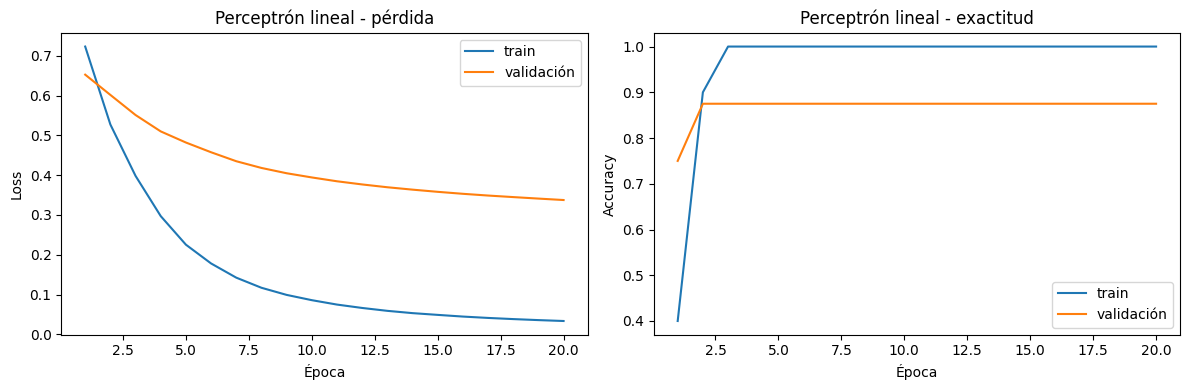

In [8]:
plot_history(linear_history, "Perceptrón lineal")

In [9]:
linear_test = evaluate_model(linear_model, X_test, y_test, nn.CrossEntropyLoss())
linear_summary = pd.DataFrame(
    {
        "modelo": ["Perceptrón lineal"],
        "test_loss": [linear_test["loss"]],
        "test_acc": [linear_test["acc"]],
        "test_f1": [linear_test["f1"]],
    }
)
linear_summary


,modelo,test_loss,test_acc,test_f1
0,Perceptrón lineal,0.777135,0.666667,0.666667


#### **Pesos más influyentes del modelo lineal**

In [10]:
weights = linear_model.weight.detach().cpu().numpy()
positive_minus_negative = weights[1] - weights[0]
idx_to_token = {idx: token for token, idx in vocab.items()}

sorted_idx = np.argsort(positive_minus_negative)
most_negative = [(idx_to_token[i], float(positive_minus_negative[i])) for i in sorted_idx[:10]]
most_positive = [(idx_to_token[i], float(positive_minus_negative[i])) for i in sorted_idx[-10:][::-1]]

print("Tokens con mayor evidencia hacia la clase NEGATIVA:")
pd.DataFrame(most_negative, columns=["token", "peso"])


Tokens con mayor evidencia hacia la clase NEGATIVA:


,token,peso
0,mala,-2.365272
1,malo,-2.313375
2,mal,-2.136318
3,lento,-1.957699
4,confusa,-1.826006
5,confuso,-1.773085
6,poco,-1.677008
7,inutil,-1.555273
8,e,-1.539261
9,descortes,-1.492140


In [11]:
print("Tokens con mayor evidencia hacia la clase POSITIVA:")
pd.DataFrame(most_positive, columns=["token", "peso"])


Tokens con mayor evidencia hacia la clase POSITIVA:


,token,peso
0,bien,2.648134
1,buena,2.149459
2,bueno,2.024645
3,rapido,1.931120
4,clara,1.738534
5,claro,1.376238
6,agradable,1.368750
7,moderna,1.348214
8,efectiva,1.310477
9,formativa,1.293748


#### **7. Baseline 2 - MLP con una capa oculta**

Ahora agregamos una capa oculta y una activación ReLU:

$$
X \rightarrow \text{Linear}(V, h) \rightarrow \text{ReLU} \rightarrow \text{Linear}(h, 2)
$$

donde:
- $V$ es el tamaño del vocabulario de entrada.
- $h$ es el número de unidades ocultas.
- $2$ es el número de clases de salida.

Esta arquitectura ya es un **MLP básico** y cumple con la parte central de la semana 3.


In [12]:
set_seed(7)
mlp_model = nn.Sequential(
    nn.Linear(len(vocab), 16),
    nn.ReLU(),
    nn.Linear(16, 2),
)

mlp_history = train_model(
    mlp_model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=20,
    lr=0.03,
    batch_size=8,
)
mlp_history.tail()


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
15,16,0.000117,1.0,1.0,0.226357,0.875,0.888889
16,17,0.000110,1.0,1.0,0.227243,0.875,0.888889
17,18,0.000104,1.0,1.0,0.228134,0.875,0.888889
18,19,0.000100,1.0,1.0,0.228913,0.875,0.888889
19,20,0.000096,1.0,1.0,0.229507,0.875,0.888889


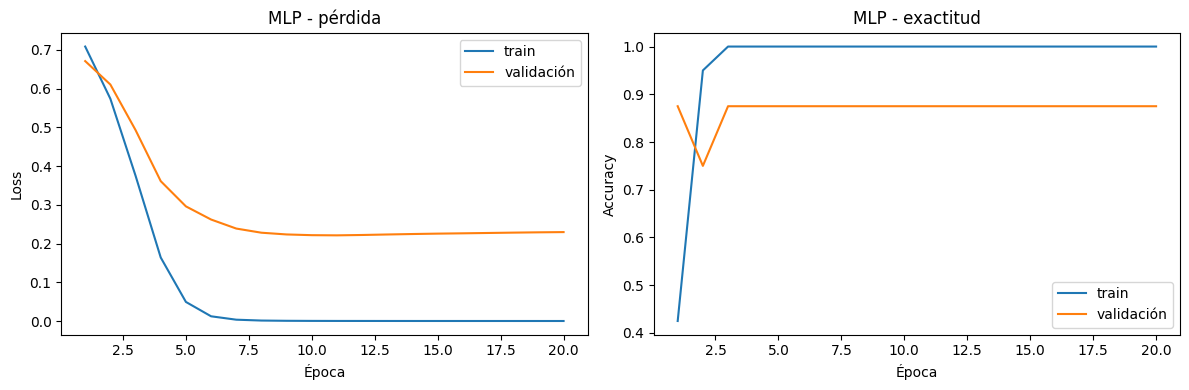

In [13]:
plot_history(mlp_history, "MLP")

In [14]:
mlp_test = evaluate_model(mlp_model, X_test, y_test, nn.CrossEntropyLoss())
comparison_df = pd.DataFrame(
    {
        "modelo": ["Perceptrón lineal", "MLP"],
        "test_loss": [linear_test["loss"], mlp_test["loss"]],
        "test_acc": [linear_test["acc"], mlp_test["acc"]],
        "test_f1": [linear_test["f1"], mlp_test["f1"]],
    }
)
comparison_df

,modelo,test_loss,test_acc,test_f1
0,Perceptrón lineal,0.777135,0.666667,0.666667
1,MLP,2.011733,0.666667,0.666667



#### **Lectura rápida de las curvas**

- Si `train_loss` baja de forma sostenida, el modelo está aprendiendo a ajustar los ejemplos de entrenamiento.
- Si `val_loss` deja de mejorar mientras `train_loss` sigue bajando, aparece sobreajuste.
- En este ejemplo el MLP ajusta muy bien el conjunto de entrenamiento, pero los casos difíciles del test siguen siendo un reto porque la representación bag-of-words **no captura bien el orden ni el alcance de la negación**.


#### **8. Análisis inicial de errores del MLP**

In [15]:
mlp_probs = mlp_test["probs"]
mlp_preds = mlp_test["preds"]

error_rows = []
for text, y_true, y_pred, probs in zip(test_texts, y_test_np, mlp_preds, mlp_probs):
    if y_true != y_pred:
        error_rows.append(
            {
                "texto": text,
                "etiqueta_real": LABELS[int(y_true)],
                "prediccion": LABELS[int(y_pred)],
                "confianza_max": float(np.max(probs)),
            }
        )

errors_df = pd.DataFrame(error_rows)
errors_df


,texto,etiqueta_real,prediccion,confianza_max
0,la documentacion fue clara pero incompleta,negativo,positivo,0.997025
1,la practica no fue frustrante,positivo,negativo,0.983249
2,el producto no es malo,positivo,negativo,0.999679
3,la pelicula no fue buena,negativo,positivo,0.997444


#### **Interpretación de errores**

Los errores más interesantes son del tipo:

- **negación**: `no fue buena`, `no es malo`, `no fue frustrante`
- **mezcla de señales**: `clara pero incompleta`, `limpio pero aburrido`

¿Por qué ocurren?

1. **Bag-of-words pierde el orden**. Para el modelo, `buena` y `no` aparecen como tokens separados, sin una noción fuerte de que la negación modifica al adjetivo.
2. **El dataset es pequeño**. El modelo ve pocos patrones de negación durante entrenamiento.
3. **La arquitectura no ve secuencia**. Aunque usamos un MLP, la entrada sigue siendo un vector de conteos, no una secuencia contextualizada.

Este resultado es útil para la sustentación oral porque permite defender no solo el entrenamiento, sino también las **limitaciones** del experimento.


#### **9. Preguntas de sustentación**

1. ¿Qué diferencia hay entre un perceptrón lineal y un MLP?
2. ¿Por qué usamos `CrossEntropyLoss` y no `MSELoss` para esta tarea?
3. ¿Qué hace exactamente `loss.backward()`?
4. ¿Por qué bag-of-words falla con ejemplos como `no es malo`?
5. ¿Qué cambiarías si quisieras mejorar este sistema sin salirte demasiado de PyTorch?


In [16]:
## Tus respuestas